<a href="https://colab.research.google.com/github/Madankk-06/Deep-learning-projects/blob/main/11_Vision_Transformer_(ViT)_Patch_Projection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import PyTorch for implementing the Vision Transformer.
import torch

# Import neural network modules.
import torch.nn as nn

# Import Einops for efficient tensor rearrangement
# and Einstein summation operations.
from einops import rearrange, einsum

# Import HuggingFace Transformers utilities.
from transformers import ViTConfig

# Import Matplotlib for visualizing attention maps.
import matplotlib.pyplot as plt

In [2]:
# Convert the input image into fixed-size patches.
# Every patch is projected into an embedding vector
# before entering the Transformer encoder.

class PatchEmbedding(nn.Module):

    def __init__(self, image_size=224, patch_size=16, embed_dim=768):

        super().__init__()

        self.patch_size = patch_size

        # Project image patches into embedding space.
        self.projection = nn.Conv2d(

            3,

            embed_dim,

            kernel_size=patch_size,

            stride=patch_size

        )

    def forward(self, x):

        # Generate patch embeddings.
        x = self.projection(x)

        # Flatten spatial patches into a sequence.
        x = rearrange(

            x,

            "b c h w -> b (h w) c"

        )

        return x

In [3]:
# Implement Multi-Head Self-Attention.
# Every attention head learns relationships
# between image patches independently.

class MultiHeadAttention(nn.Module):

    def __init__(self, embed_dim=768, heads=8):

        super().__init__()

        self.heads = heads

        self.scale = embed_dim ** -0.5

        # Generate Query, Key, and Value matrices.
        self.qkv = nn.Linear(

            embed_dim,

            embed_dim * 3

        )

        # Project concatenated attention outputs.
        self.output = nn.Linear(

            embed_dim,

            embed_dim

        )

    def forward(self, x):

        # Compute Query, Key, and Value representations.
        qkv = self.qkv(x)

        q, k, v = qkv.chunk(3, dim=-1)

        # Split embeddings across multiple attention heads.
        q = rearrange(q, "b n (h d) -> b h n d", h=self.heads)

        k = rearrange(k, "b n (h d) -> b h n d", h=self.heads)

        v = rearrange(v, "b n (h d) -> b h n d", h=self.heads)

        # Compute attention scores using
        # Einstein summation notation.
        attention = einsum(

            q,

            k,

            "b h i d, b h j d -> b h i j"

        ) * self.scale

        attention = attention.softmax(dim=-1)

        # Aggregate contextual information
        # from all attended image patches.
        output = einsum(

            attention,

            v,

            "b h i j, b h j d -> b h i d"

        )

        output = rearrange(

            output,

            "b h n d -> b n (h d)"

        )

        return self.output(output), attention

In [4]:
# Construct a Vision Transformer block.
# Learnable Class Token summarizes
# the entire image representation.
# Positional Embeddings preserve
# spatial patch ordering.

class VisionTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = PatchEmbedding()

        self.class_token = nn.Parameter(

            torch.randn(1,1,768)

        )

        self.position = nn.Parameter(

            torch.randn(1,197,768)

        )

        self.attention = MultiHeadAttention()

    def forward(self,x):

        # Convert image into patch embeddings.
        x = self.embedding(x)

        batch = x.shape[0]

        # Append the learnable Class Token.
        cls = self.class_token.expand(batch,-1,-1)

        x = torch.cat([cls,x],dim=1)

        # Add positional information to every patch.
        x = x + self.position

        # Compute Multi-Head Self-Attention.
        output, attention = self.attention(x)

        return output, attention

In [5]:
# Create the Vision Transformer model.

model = VisionTransformer()

In [6]:
# Generate a high-resolution image
# for patch extraction and attention learning.

image = torch.randn(

    2,

    3,

    224,

    224

)

In [7]:
# Perform Vision Transformer inference.

output, attention = model(image)

In [8]:
# Verify patch embedding dimensions
# and attention matrix dimensions.

print("Transformer Output :", output.shape)

print("Attention Shape :", attention.shape)

Transformer Output : torch.Size([2, 197, 768])
Attention Shape : torch.Size([2, 8, 197, 197])


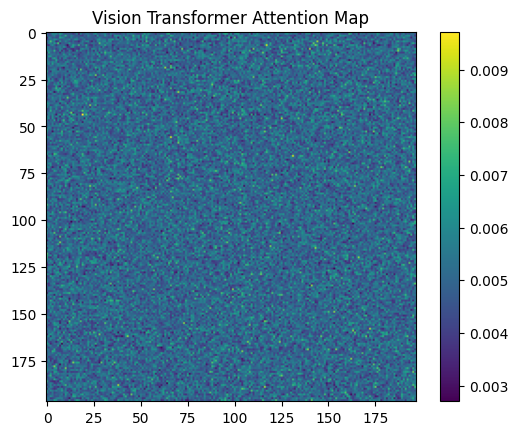

In [9]:
# Display one attention map learned
# by the first attention head.

plt.imshow(

    attention[0,0].detach().numpy(),

    cmap="viridis"

)

plt.title("Vision Transformer Attention Map")

plt.colorbar()

plt.show()